# Constructing a forensic Bayesian network with integrated Y-STR matching evidence

## Imports

In [53]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.image as gumimage
from itertools import combinations
import pyagrum.skbn as skbn
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import pyagrum.lib.bn_vs_bn as bnvsbn

## Constructing the Bayesian Network

### Variables

In [2]:
bn = gum.BayesNet("Y_STR_Familial_Search")

relationship = bn.add(
    gum.LabelizedVariable(
        "Relationship",
        "relationship",
        [
            "close_relation",
            "distant_relation",
            "unrelated"
        ]
    )
)

hap_freq = bn.add(
    gum.LabelizedVariable(
        "HaplotypeFrequency",
        "haplotype frequency",
        ["rare", "common"]
    )
)

observed_match = bn.add(
    gum.LabelizedVariable(
        "ObservedMatch",
        "observed match",
        ["match", "no_match"]
    )
)

genetic_evidence = bn.add(
    gum.LabelizedVariable(
        "GeneticEvidence",
        "genetic evidence",
        ["strong", "weak"]
    )
)

investigative_leads = bn.add(
    gum.LabelizedVariable(
        "InvestigativeLeads",
        "Strength of genealogical investigation",
        ["useful", "not_useful"]
    )
)

other_evidence = bn.add(
    gum.LabelizedVariable(
        "OtherEvidence",
        "Strength of non-DNA evidence",
        ["supportive", "neutral", "not_supportive"]
    )
)

evidence_strength = bn.add(
    gum.LabelizedVariable(
        "EvidenceStrength",
        "Overall evidence that offender belongs to the lineage",
        ["strong", "weak"]
    )
)

### Connections

In [3]:
bn.addArc("Relationship", "ObservedMatch")
bn.addArc("HaplotypeFrequency", "GeneticEvidence")
bn.addArc("ObservedMatch", "GeneticEvidence")
bn.addArc("Relationship", "InvestigativeLeads")
bn.addArc("GeneticEvidence", "EvidenceStrength")
bn.addArc("InvestigativeLeads", "EvidenceStrength")
bn.addArc("OtherEvidence", "EvidenceStrength")

bn

(pyagrum.BayesNet@0000019D099C46C0) BN{nodes: 7, arcs: 7, domainSize: 288, dim: 27, mem: 416o}

### CPTs

In [4]:
##########################################
# Relationship {close relation, distant relation, unrelated}
bn.cpt("Relationship").fillWith([0.1, 0.2, 0.8])

##########################################
# Haplotype Frequency {rare, common}
bn.cpt("HaplotypeFrequency").fillWith([0.1, 0.9])

##########################################
# Observed match {match, no_match}
bn.cpt("ObservedMatch")[{
    "Relationship": "close_relation",
}] = [0.9, 0.1]

bn.cpt("ObservedMatch")[{
    "Relationship": "distant_relation",
}] = [0.7, 0.3]

bn.cpt("ObservedMatch")[{
    "Relationship": "unrelated",
}] = [0.2, 0.8]

##########################################
# Investigative leads {useful, not useful}
bn.cpt("InvestigativeLeads")[{
    "Relationship": "close_relation"}] = [0.85, 0.15]

bn.cpt("InvestigativeLeads")[{
    "Relationship": "distant_relation"}] = [0.6, 0.4]

bn.cpt("InvestigativeLeads")[{
    "Relationship": "unrelated"}] = [0.1, 0.9]

##########################################
# Other evidence {supportive, neutral, unsupportive}
bn.cpt("OtherEvidence").fillWith([0.33, 0.33, 0.34])

##########################################
# Genetic evidence {strong, weak}
bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "match",
    "HaplotypeFrequency": "rare"
}] = [0.9, 0.1]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "match",
    "HaplotypeFrequency": "common"
}] = [0.7, 0.3]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "no_match",
    "HaplotypeFrequency": "rare"
}] = [0.2, 0.8]

bn.cpt("GeneticEvidence")[{
    "ObservedMatch": "no_match",
    "HaplotypeFrequency": "common"
}] = [0.1, 0.9]

##########################################
# Overall evidence strength {strong, weak}
bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "supportive"
}] = [0.95, 0.05]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "neutral"
}] = [0.8, 0.2]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "not_supportive"
}] = [0.7, 0.3]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "supportive"
}] = [0.85, 0.15]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "neutral"
}] = [0.6, 0.4]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "strong",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "not_supportive"
}] = [0.4, 0.6]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "supportive"
}] = [0.6, 0.4]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "neutral"
}] = [0.5, 0.5]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "useful",
    "OtherEvidence": "not_supportive"
}] = [0.3, 0.7]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "supportive"
}] = [0.25, 0.75]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "neutral"
}] = [0.15, 0.85]

bn.cpt("EvidenceStrength")[{
    "GeneticEvidence": "weak",
    "InvestigativeLeads": "not_useful",
    "OtherEvidence": "not_supportive"
}] = [0.05, 0.95]

In [5]:
row = []
for node in bn.names():
    row.append(bn.cpt(node))

gnb.flow.row(*row)

## Inference examples

### No observations
Given no observations, the expactation is that the Overall EvidenceStrength tends to be weak. 
This is caused by the fact that relationships to individuals in a population have a higher probability on being unrelated. 
This combined with common haplotypes having high probability and observed matches having low probabilities on unrelated people makes Genetic evidence weak.
Investigative leads on unrelated individuals also have low probability and the supportiveness of other evidence doesn't help much either.

The results here are as expected

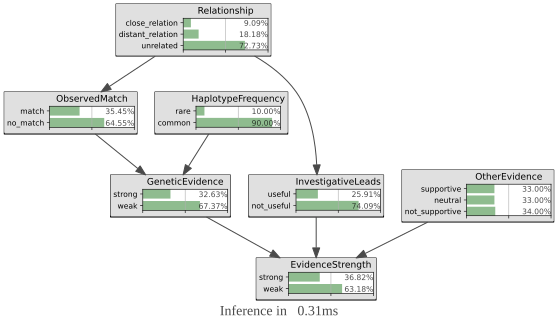

In [6]:
gnb.showInference(bn, evs={})

### Observing a genetic match
Observing a match should increase the probability for strong genetic evidence somewhat and thus influence overall evidence strength as well.

The genetic evidence has increased a lot actually together with overall evidence strength. 
This is caused by the effect of an observed match which also increased the believe in a close or distant relationship in favor of an unrelated individual, which in turn influences investigative leads, that also has leads to an increase on overall evidence.
The higher believe in a close or distant relationship is propagated back through the network also increasing genetic evidence again.
One more nice thing to see here is that the collider construction blocks this propagation of relationship and does not influence Haplotype, which is exactly right. A relationship between individuals does not inform about the haplotype.

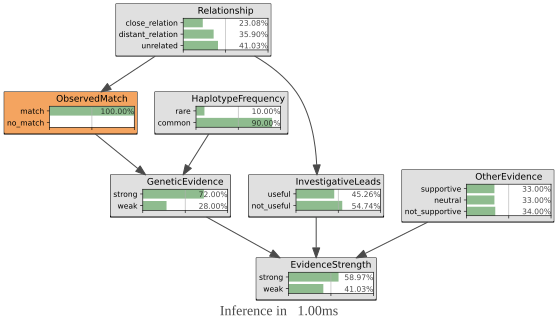

In [7]:
gnb.showInference(bn, evs={"ObservedMatch":"match"})

### Observing a rare haplotype
Given the isolated position of the Haplotype behind a collider it can only influence the genetic evidence and overall evidence strength. Overall evidence strength also blocks the propagation through its collider function.

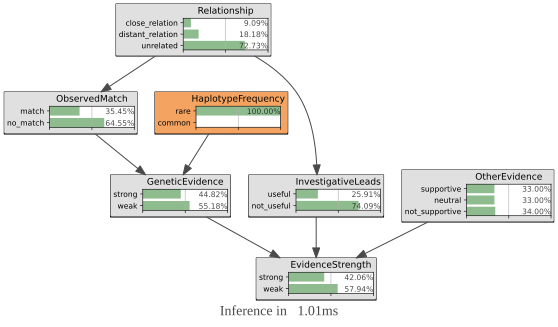

In [8]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare"})

### Observing a rare haplotype and a genetic match
Observing both a match and the rare haplotype frequency should increase the overall evidence/genetic evidence more substantially than just the observed match.
The other variables shouldn't be different because of the isolated position of the haplotype frequency variable

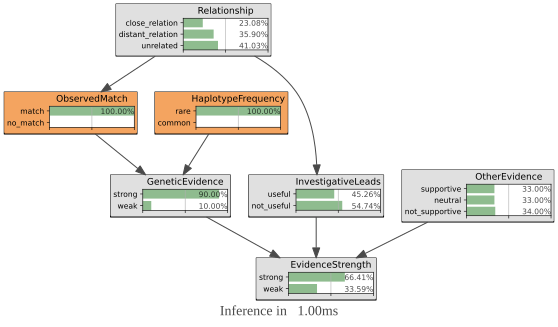

In [9]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match"})

### Some more inference experiments

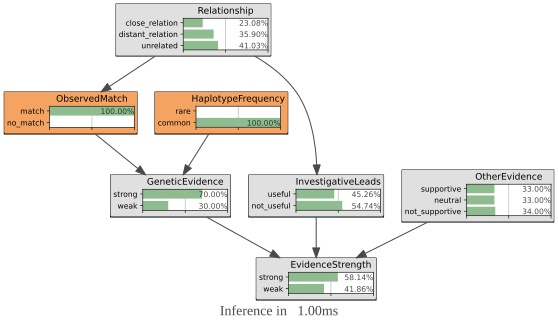

In [10]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "common", "ObservedMatch":"match"})

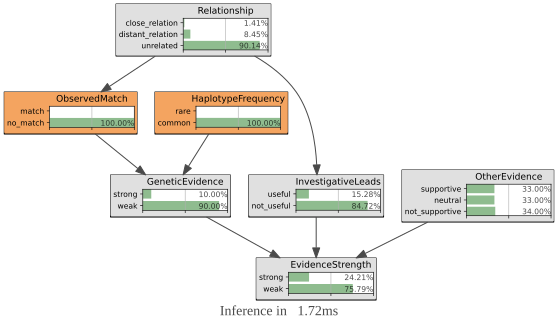

In [11]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "common", "ObservedMatch":"no_match"})

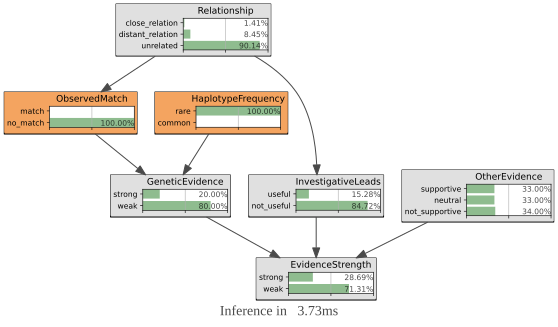

In [12]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"no_match"})

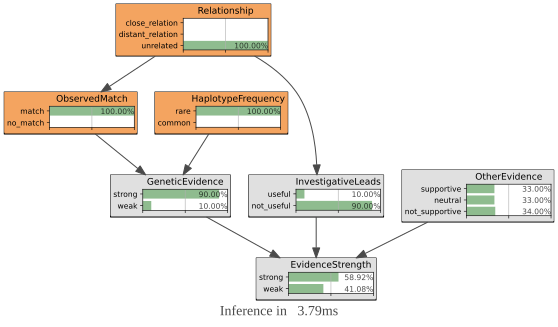

In [13]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "Relationship": "unrelated"})

### Genetic evidence is all you need?
The following inference experiments show that genetic evidence alone has effect, but can not be the only evidence to convict a suspect.
Nor can a different type of evidence be enough

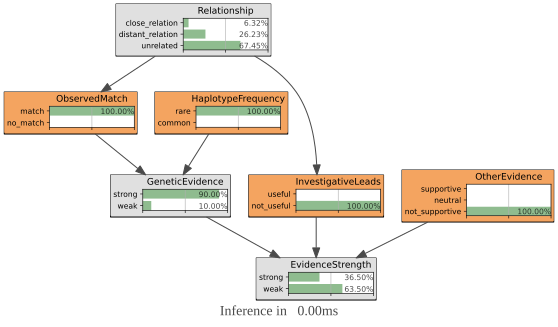

In [14]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "InvestigativeLeads": "not_useful", "OtherEvidence":"not_supportive"})

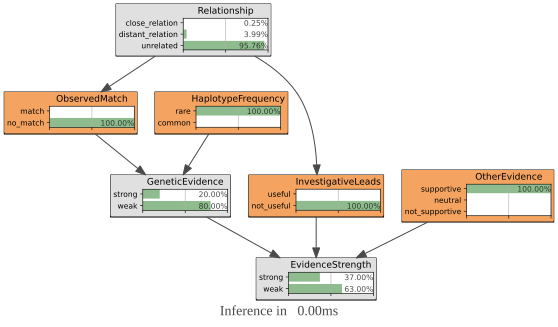

In [15]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"no_match", "InvestigativeLeads": "not_useful", "OtherEvidence":"supportive"})

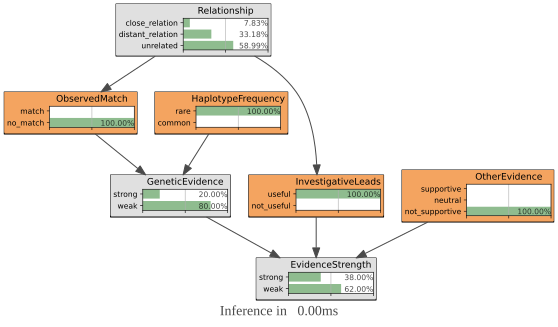

In [16]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"no_match", "InvestigativeLeads": "useful", "OtherEvidence":"not_supportive"})

### All together

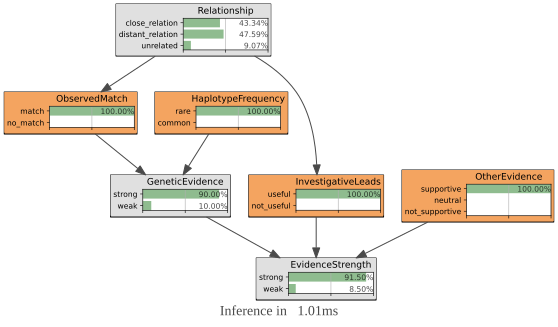

In [17]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "InvestigativeLeads": "useful", "OtherEvidence":"supportive"})

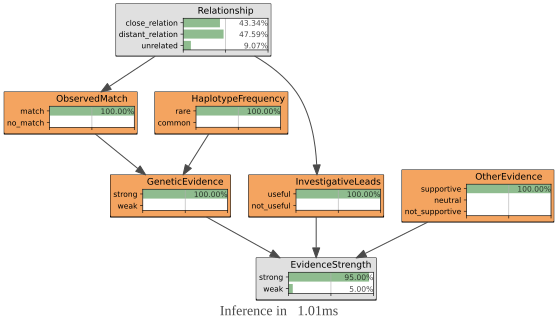

In [18]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "InvestigativeLeads": "useful", "OtherEvidence":"supportive", "GeneticEvidence": "strong"})


### One more thing
One more interesting effect: Given the observed match and investigative leads, knowing the actual relationship does not have an effect on overall evidence anymore, because all patch have been blocked by the conditioning set.

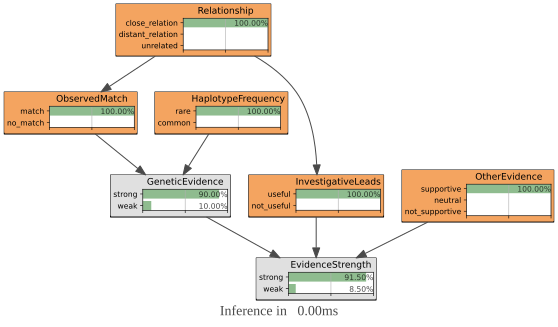

In [19]:
gnb.showInference(bn, evs={"HaplotypeFrequency": "rare", "ObservedMatch":"match", "InvestigativeLeads": "useful", "OtherEvidence":"supportive", "Relationship": "close_relation"})

# Relearning the structure with generated data

## PC algorithm
### Independencies
First draw independencies from the constructed bayesian network

In [20]:
nodes = ["Relationship", "ObservedMatch","InvestigativeLeads","HaplotypeFrequency","OtherEvidence","GeneticEvidence", "EvidenceStrength"]

def independence_loop(nodes, test, learner=None):
    for x, y in combinations(nodes, 2):
        remaining = [z for z in nodes if z not in (x,y)]
    
        found = False
        # generate subsets
        for r in range(4):
            if found:
                break
            
            for cond in combinations(remaining, r):
                cond_ids = {bn.idFromName(z) for z in cond}
                
                if test(x, y, cond, learner):
                    print(f'{x} || {y} | {cond}')
                    found = True

def dag_test(x, y, cond, learner):
    dag = bn.dag()
    return dag.dSeparation(
        bn.idFromName(x),
        bn.idFromName(y),
        {bn.idFromName(z) for z in cond}
    )

In [21]:
print("indepencies in the DAG: ")
independence_loop(nodes, dag_test)

indepencies in the DAG: 
Relationship || HaplotypeFrequency | ()
Relationship || OtherEvidence | ()
Relationship || GeneticEvidence | ('ObservedMatch',)
Relationship || EvidenceStrength | ('ObservedMatch', 'InvestigativeLeads')
Relationship || EvidenceStrength | ('InvestigativeLeads', 'GeneticEvidence')
ObservedMatch || InvestigativeLeads | ('Relationship',)
ObservedMatch || HaplotypeFrequency | ()
ObservedMatch || OtherEvidence | ()
ObservedMatch || EvidenceStrength | ('Relationship', 'GeneticEvidence')
ObservedMatch || EvidenceStrength | ('InvestigativeLeads', 'GeneticEvidence')
InvestigativeLeads || HaplotypeFrequency | ()
InvestigativeLeads || OtherEvidence | ()
InvestigativeLeads || GeneticEvidence | ('Relationship',)
InvestigativeLeads || GeneticEvidence | ('ObservedMatch',)
HaplotypeFrequency || OtherEvidence | ()
HaplotypeFrequency || EvidenceStrength | ('Relationship', 'GeneticEvidence')
HaplotypeFrequency || EvidenceStrength | ('ObservedMatch', 'GeneticEvidence')
HaplotypeFre

## Remove connections based on dependencies
Next use the PC algorithm to remove connections based on the indepencies.

### Starting point fully connected

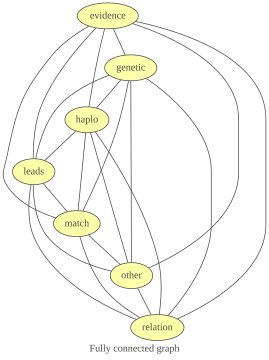

In [22]:
mn = gum.fastMRF("relation----match;relation--haplo;relation--other;relation--genetic;relation--evidence;relation--leads;match--haplo;match--other;match--genetic;match--leads;match--evidence;haplo--other;haplo--genetic;haplo--evidence;haplo--leads;other--genetic;other--evidence;other--leads;genetic--evidence;genetic--leads;evidence--leads")
mn.setProperty("name", "Fully connected graph")
gnb.showDot(mn.toDot())

### Remove connections based on empty conditioning sets


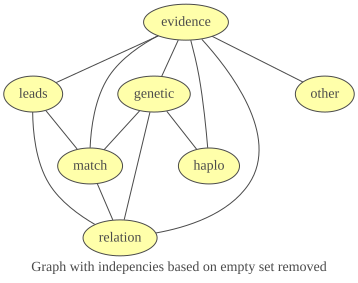

In [23]:
mn = gum.fastMRF("relation----match;relation--genetic;relation--evidence;relation--leads;match--genetic;match--leads;match--evidence;haplo--genetic;haplo--evidence;other--evidence;genetic--evidence;evidence--leads")
mn.setProperty("name", "Graph with indepencies based on empty set removed")
gnb.showDot(mn.toDot())

### Remove connections based on conditioning sets of size one


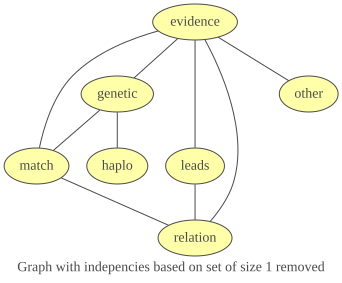

In [24]:
mn = gum.fastMRF("relation----match;relation--evidence;relation--leads;match--genetic;match--evidence;haplo--genetic;other--evidence;genetic--evidence;evidence--leads")
mn.setProperty("name", "Graph with indepencies based on set of size 1 removed")
gnb.showDot(mn.toDot())

### Remove connections based on conditioning sets of size two

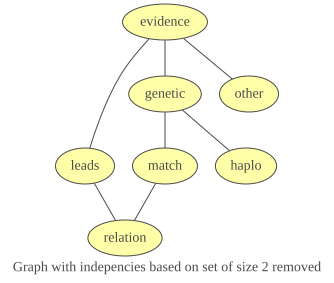

In [25]:
mn = gum.fastMRF("relation----match;relation--leads;match--genetic;haplo--genetic;other--evidence;genetic--evidence;evidence--leads")
mn.setProperty("name", "Graph with indepencies based on set of size 2 removed")
gnb.showDot(mn.toDot())

### DONE!

In [26]:
## add colliders x-z-y where X || Y and Z not in seperator set
# match - genetic - haplo => match -> genetic <- haplot, since match || haplo | {}
# leads - evidence - genetic => leads -> evidence <- genetic, since leads || genetic | {}
# leads - evidence - other => leads -> evidence <- other, since leads || other | {}
# other - evidence - genetic => other -> evidence <- genetic, since other || genetic | {}

## no other rules apply here 
# leaving: relation-match and relation-leads open and these could be oriented like leads <- relation -> match or leads -> relation -> match or leads <- relation <- match which cannot be learned from the data.

# It could lead to our original framework, but also two Markov equivalent ones

## Generating Data

In [27]:
def generate_data(gen, size=100):
    gen.drawSamples(size)
    return gen.to_pandas()

In [28]:
gen = gum.BNDatabaseGenerator(bn)

df_100 = generate_data(gen)
df_500 = generate_data(gen, 500)
df_1000 = generate_data(gen, 1000)

## Exploring indepencies in the data

In [29]:
learner_100 = gum.BNLearner(df_100, bn)
learner_500 = gum.BNLearner(df_500, bn)
learner_1000 = gum.BNLearner(df_1000, bn)

alpha = 0.05
def learn_test(x, y, cond, learner):
    statistic, pvalue = learner.chi2(x, y, list(cond))
    return pvalue > alpha

print("indepencies in generated data according to learner_100: ")
independence_loop(nodes, learn_test, learner_100)
print("")
print("")
print("indepencies in generated data according to learner_500: ")
independence_loop(nodes, learn_test, learner_500)
print("")
print("")
print("indepencies in generated data according to learner_1000: ")
independence_loop(nodes, learn_test, learner_1000)

indepencies in generated data according to learner_100: 
Relationship || ObservedMatch | ('InvestigativeLeads', 'HaplotypeFrequency', 'OtherEvidence')
Relationship || ObservedMatch | ('InvestigativeLeads', 'HaplotypeFrequency', 'GeneticEvidence')
Relationship || ObservedMatch | ('InvestigativeLeads', 'OtherEvidence', 'GeneticEvidence')
Relationship || ObservedMatch | ('HaplotypeFrequency', 'OtherEvidence', 'GeneticEvidence')
Relationship || ObservedMatch | ('HaplotypeFrequency', 'OtherEvidence', 'EvidenceStrength')
Relationship || InvestigativeLeads | ('ObservedMatch', 'OtherEvidence', 'EvidenceStrength')
Relationship || HaplotypeFrequency | ()
Relationship || OtherEvidence | ()
Relationship || GeneticEvidence | ('ObservedMatch',)
Relationship || GeneticEvidence | ('InvestigativeLeads',)
Relationship || GeneticEvidence | ('HaplotypeFrequency',)
Relationship || GeneticEvidence | ('EvidenceStrength',)
Relationship || EvidenceStrength | ('ObservedMatch',)
Relationship || EvidenceStrength 

## Relearning

### Constrained based: MIIC
Works like PC by inferring the structure by performing independence tests

#### 100 samples learning MIIC

In [30]:
bn_100_MIIC = learner_100.learnBN()
bn_100_MIIC

(pyagrum.BayesNet@0000019D099C69A0) BN{nodes: 7, arcs: 5, domainSize: 288, dim: 17, mem: 248o}

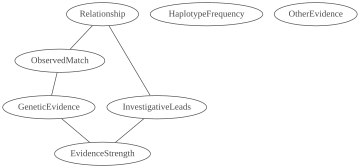

In [31]:
essential_100_MIIC = learner_100.learnEssentialGraph()
gnb.show(essential_100_MIIC)

In [57]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_100_MIIC),
    bnvsbn.graphDiff(bn_100_MIIC, bn),
    bnvsbn.graphDiffLegend()
)

#### 500 samples learning MIIC

In [32]:
bn_500_MIIC = learner_500.learnBN()
bn_500_MIIC

(pyagrum.BayesNet@0000019D099C5830) BN{nodes: 7, arcs: 7, domainSize: 288, dim: 22, mem: 304o}

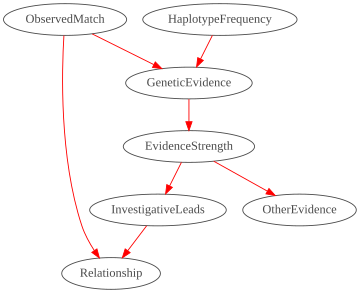

In [33]:
essential_500_MIIC = learner_500.learnEssentialGraph()
gnb.show(essential_500_MIIC)

In [58]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_500_MIIC),
    bnvsbn.graphDiff(bn_500_MIIC, bn),
    bnvsbn.graphDiffLegend()
)

#### 1000 samples learning MIIC

In [34]:
bn_1000_MIIC = learner_1000.learnBN()
bn_1000_MIIC

(pyagrum.BayesNet@0000019D099C6F70) BN{nodes: 7, arcs: 6, domainSize: 288, dim: 22, mem: 328o}

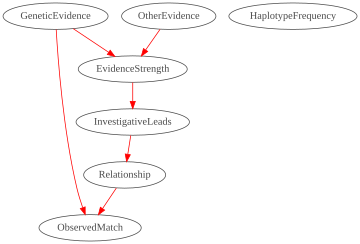

In [35]:
essential_1000_MIIC = learner_1000.learnEssentialGraph()
gnb.show(essential_1000_MIIC)

In [59]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_1000_MIIC),
    bnvsbn.graphDiff(bn_1000_MIIC, bn),
    bnvsbn.graphDiffLegend()
)

### Search-and-score based: Greedy Hill Climbing (GHC)
Searches through possible DAGs and optimizes a score with BIC

In [36]:
learner_100_GHC = gum.BNLearner(df_100, bn)
learner_500_GHC = gum.BNLearner(df_500, bn)
learner_1000_GHC = gum.BNLearner(df_1000, bn)

learner_100_GHC.useGreedyHillClimbing()
learner_500_GHC.useGreedyHillClimbing()
learner_1000_GHC.useGreedyHillClimbing()

(pyagrum.BNLearner@0000019D0AC2F040) Filename       : C:\Users\jurge\AppData\Local\Temp\tmplpnxs6vn.csv
Size           : (1000,7)
Variables      : Relationship[3], HaplotypeFrequency[2], ObservedMatch[2], GeneticEvidence[2], InvestigativeLeads[2], OtherEvidence[3], EvidenceStrength[2]
Induced types  : False
Missing values : False
Algorithm      : Greedy Hill Climbing
Score          : BDeu
Prior          : -

#### 100 samples learning GHC

In [37]:
bn_100_GHC = learner_100_GHC.learnBN()
bn_100_GHC

(pyagrum.BayesNet@0000019D099C5E00) BN{nodes: 7, arcs: 4, domainSize: 288, dim: 15, mem: 216o}

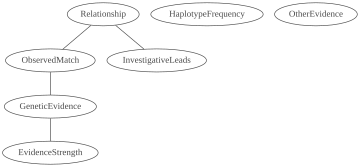

In [38]:
essential_100_GHC = learner_100_GHC.learnEssentialGraph()
gnb.show(essential_100_GHC)

In [60]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_100_GHC),
    bnvsbn.graphDiff(bn_100_GHC, bn),
    bnvsbn.graphDiffLegend()
)

#### 500 samples learning GHC

In [39]:
bn_500_GHC = learner_500_GHC.learnBN()
bn_500_GHC

(pyagrum.BayesNet@0000019D099C9DF0) BN{nodes: 7, arcs: 7, domainSize: 288, dim: 21, mem: 304o}

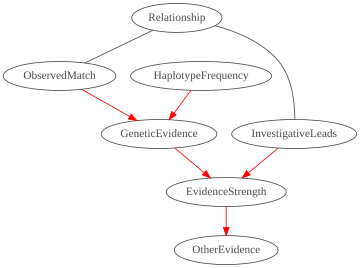

In [40]:
essential_500_GHC = learner_500_GHC.learnEssentialGraph()
gnb.show(essential_500_GHC)

In [61]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_500_GHC),
    bnvsbn.graphDiff(bn_500_GHC, bn),
    bnvsbn.graphDiffLegend()
)

#### 1000 samples learning GHC

In [41]:
bn_1000_GHC = learner_1000_GHC.learnBN()
bn_1000_GHC

(pyagrum.BayesNet@0000019D099C80E0) BN{nodes: 7, arcs: 8, domainSize: 288, dim: 26, mem: 376o}

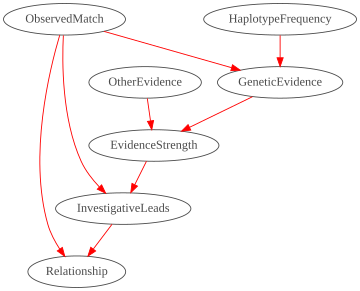

In [42]:
essential_1000_GHC = learner_1000_GHC.learnEssentialGraph()
gnb.show(essential_1000_GHC)

In [62]:
gnb.flow.row(
    bnvsbn.graphDiff(bn, bn_1000_GHC),
    bnvsbn.graphDiff(bn_1000_GHC, bn),
    bnvsbn.graphDiffLegend()
)

Haplotype Frequency almost seems useless. What about the dependencies? It always seems to be independent, which in case is true, probably because of the isolated position. But it should have influence on geneticevidence as well....

    One experiment with 10.000 samples?

# Classifier

## Generate train and test data

## Performance comparison between:
- original network
- relearned structure + parameters
- Naive bayes

In [45]:
bnc = skbn.BNClassifier()
bnc.fromTrainedModel(bn, targetAttribute="EvidenceStrength")

train_df = generate_data(gen)
train_df.to_csv("train.csv", index=False)

test_df = generate_data(gen)
test_df.to_csv("test.csv", index=False)

xTrain, yTrain = bnc.XYfromCSV(filename="train.csv")
xTest, yTest = bnc.XYfromCSV(filename="test.csv")

# encode features and targets for CategoricalNB model
enc = OrdinalEncoder()
X_train_enc = enc.fit_transform(xTrain)
X_test_enc = enc.transform(xTest)

le = LabelEncoder()
y_train_enc = le.fit_transform(yTrain)
y_test_enc = le.transform(yTest)

In [46]:
def test_model(model, X, y):
    cv = cross_validate(model, X, y, cv=5)
    print(f"scores with cross-folding : {cv['test_score']}")
    print()
    print(f"mean score : {cv['test_score'].mean()}")
    
    model.showROC_PR("test.csv")

In [47]:
# Original model
clf_BN = skbn.BNClassifier()
clf_BN.fromTrainedModel(bn, targetAttribute="EvidenceStrength")

In [49]:
# Greedy Hill Climber BN as classifier model
learner_GHC = gum.BNLearner(train_df, bn)
learner_GHC.useGreedyHillClimbing()
bn_GHC = learner_GHC.learnBN()

clf_GHC = skbn.BNClassifier()
clf_GHC.fromTrainedModel(bn_GHC, targetAttribute="EvidenceStrength")

In [51]:
# Naive bayes
clf_NB = CategoricalNB()
clf_NB.fit(X_train_enc, y_train_enc)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


Original BN
scores with cross-folding : [0.75 0.6  0.75 0.6  0.8 ]

mean score : 0.7


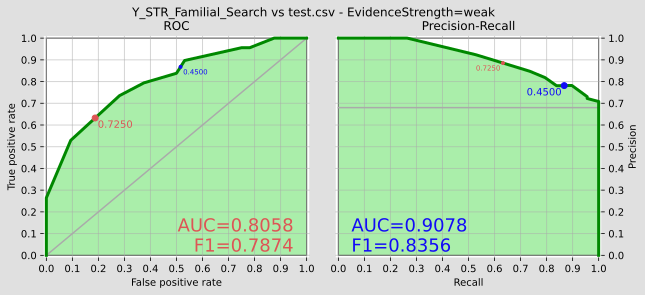


Relearned Structure + params Greedy Hill Climbing
scores with cross-folding : [0.75 0.6  0.75 0.6  0.8 ]

mean score : 0.7


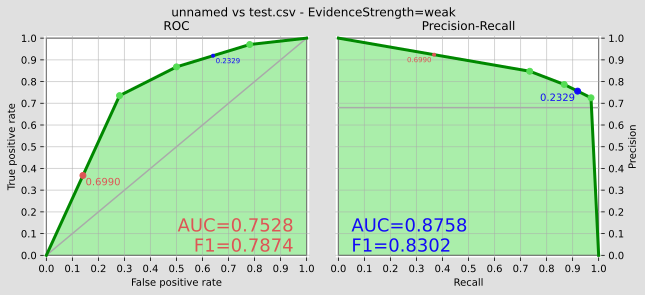


Naive bayes classifier


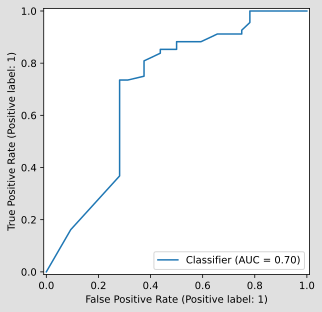

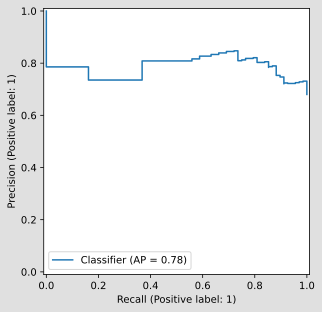

PR_AUC: 0.7999319976676003


In [52]:
# test models
print("Original BN")
test_model(clf_BN, xTest, yTest)
print()

print("Relearned Structure + params Greedy Hill Climbing")
test_model(clf_GHC, xTest, yTest)
print()

print("Naive bayes classifier")
cv = cross_validate(clf_NB, X_test_enc, y_test_enc, cv=5)
y_score = clf_NB.predict_proba(X_test_enc)[:, 1]
precision, recall, _ = precision_recall_curve(y_test_enc, y_score)
pr_auc = auc(recall, precision)

# ROC curve
RocCurveDisplay.from_predictions(y_test_enc, y_score)
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test_enc, y_score)
plt.show()
print(f"PR_AUC: {pr_auc}")